In [1]:
import matplotlib
import matplotlib.pyplot as plt

import numpy as np
import os
path = os.getcwd()

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

np.set_printoptions(precision=4)

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 12
       }

plt.rcParams['axes.grid'] = True
matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=12) 
matplotlib.rc('ytick', labelsize=12) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
    
%load_ext autoreload
%autoreload 2 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
def plot_fig(i, control):
    lines = 2
    height = lines * 3
    fig, axes = plt.subplots(lines,2, figsize=(18, height))
    axes[0,i].plot(aln.t, control[0,0,:], label="control exc")
    axes[0,i+1].plot(aln.t, control[0,1,:], label="control inh")
    axes[1,i].plot(aln.t, aln.state["rates_exc"][0,:], label="rates exc")
    axes[1,i+1].plot(aln.t, aln.state["rates_inh"][0,:], label="rates inh")
    
    """
    axes[2,i].plot(aln.t, aln.state["mufe"][0,:], label="mufe")
    axes[2,i+1].plot(aln.t, aln.state["mufi"][0,:], label="mufi")
    #axes[3,i].plot(aln.t, aln.state["IA"][0,:], label="IA")

    axes[4,i].plot(aln.t, aln.state["seem"][0,:], label="seem")
    axes[3,i].plot(aln.t, aln.state["seim"][0,:], label="seim")
    axes[4,i+1].plot(aln.t, aln.state["siem"][0,:], label="siem")
    axes[3,i+1].plot(aln.t, aln.state["siim"][0,:], label="siim")

    axes[5,i].plot(aln.t, aln.state["seev"][0,:], label="seev")
    axes[5,i+1].plot(aln.t, aln.state["seiv"][0,:], label="seiv")
    axes[6,i].plot(aln.t, aln.state["siev"][0,:], label="siev")
    axes[6,i+1].plot(aln.t, aln.state["siiv"][0,:], label="siiv")

    #axes[6,i].plot(aln.t, aln.state["mue_ou"][0,:], label="mue_ou")
    #axes[6,i+1].plot(aln.t, aln.state["mui_ou"][0,:], label="mui_ou")

    axes[7,i].plot(aln.t, aln.state["sigmae_f"][0,:], label="sigma_e")
    axes[7,i+1].plot(aln.t, aln.state["sigmai_f"][0,:], label="sigma_i")
    #axes[8,i].plot(aln.t, aln.state["Vmean_exc"][0,:], label="V_mean")
    #axes[9,i].plot(aln.t, aln.state["tau_exc"][0,:], label="tau_exc")
    #axes[9,i+1].plot(aln.t, aln.state["tau_inh"][0,:], label="tau_inh")
    """

    for k in range(lines):
        for j in range(2):
            #if ((k,j) != (3,1) and (k,j) != (8,1)):
            axes[k,j].legend()

    plt.tight_layout()
    
def plot_dif(diff_):
    fig, axes = plt.subplots(1,2, figsize=(18, 3))
    axes[0].plot(aln.t, diff_[0,:], label="difference in exc rate")
    axes[1].plot(aln.t, diff_[1,:], label="difference in inh rate")

    for j in range(2):
        axes[j].legend()

    plt.tight_layout()
    
def plot_phi(phi):
    lines = 9
    time = np.arange(0, dur+aln.params.dt, aln.params.dt)
    
    fig, axes = plt.subplots(lines,2, figsize=(18, 26))
    
    axes[0,0].plot(time, phi[0,0,:], label="phi0 - adjoint exc rate")
    axes[0,1].plot(time, phi[0,1,:], label="phi1 - adjoint inh rate")
    
    axes[1,0].plot(time, phi[0,2,:], label="phi2 - adjoint mufe")
    axes[1,1].plot(time, phi[0,3,:], label="phi3 - adjoint mufi")
    
    axes[2,0].plot(time, phi[0,6,:], label="phi6 - adjoint seim")
    axes[2,1].plot(time, phi[0,8,:], label="phi8 - adjoint siim")
    
    axes[3,0].plot(time, phi[0,4,:], label="phi4 - adjoint IA")
    axes[3,1].plot(time, phi[0,17,:], label="phi17 - adjoint V")
    
    axes[4,0].plot(time, phi[0,5,:], label="phi6 - adjoint seem")
    axes[4,1].plot(time, phi[0,7,:], label="phi8 - adjoint siem")
    
    axes[5,0].plot(time, phi[0,9,:], label="phi9 - adjoint seev")
    axes[5,0].plot(time, phi[0,10,:], label="phi10 - adjoint seiv")
    axes[5,1].plot(time, phi[0,11,:], label="phi11 - adjoint siev")
    axes[5,1].plot(time, phi[0,12,:], label="phi12 - adjoint siiv")
    
    axes[6,0].plot(time, phi[0,13,:], label="phi13 - adjoint mue ou")
    axes[6,1].plot(time, phi[0,14,:], label="phi14 - adjoint mui ou")
    
    axes[7,0].plot(time, phi[0,15,:], label="phi15 - adjoint sigma e")
    axes[7,1].plot(time, phi[0,16,:], label="phi16 - adjoint sigma i")
    
    axes[8,0].plot(time, phi[0,18,:], label="phi18 - adjoint tau e")
    axes[8,1].plot(time, phi[0,19,:], label="phi19 - adjoint tau i")

    for k in range(lines):
        for j in range(2):
            axes[k,j].legend()

    plt.tight_layout()

def diff_control(diff_):
    d_int = 0.
    for n in range(diff_.shape[0]):
        for v in range(diff_.shape[1]):
            for t in range(diff_.shape[2]):
                d_int += np.abs(diff_[n,v,t]) * aln.params.dt
    return d_int
            
def setparams():
    
    # default
    aln.params.mue_ext_mean = 0.4
    aln.params.mui_ext_mean = 0.3
    
    aln.params.sigmae_ext = 1.5
    aln.params.sigmai_ext = 1.5
    
    aln.params.ext_exc_current = 0.
    aln.params.ext_inh_current = 0.
    
    aln.params.di = 0.0
    aln.params.de = 0.0
    aln.params.signalV = 0.
    
def set_init(init_v_):
    init_vars = aln.init_vars
    for i in range(len(init_vars)):
        if aln.params[init_vars[i]].size == 1:
            aln.params[init_vars[i]][0] = init_v_[i]
        else:
            aln.params[init_vars[i]][0,-1] = init_v_[i]
    
rates_exc_init = np.array( [[ 33. ]] )
rates_inh_init = np.array( [[44. ]] )
mufe_init = np.array( [[1.5 ]] )  # mV/ms
mufi_init = np.array( [[1.5 ]] )  # mV/ms
IA_init = np.array( [[100. ]] )  # pA
seem_init = np.array( [[0.5 * 0.5 ]] )
seim_init = np.array( [[0.5 * 0.5 ]] )   
seev_init = np.array( [[0.01 * 0.5 ]] )
seiv_init = np.array( [[0.01 * 0.5 ]] )
siim_init = np.array( [[0.5 * 0.5 ]] )
siem_init = np.array( [[0.5 * 0.5 ]] )
siiv_init = np.array( [[0.01 * 0.5 ]] )
siev_init = np.array( [[0.01 * 0.5 ]] )
mue_ou = np.array( [[0.4 ]] )
mui_ou = np.array( [[0.3 ]] )

initvars = np.array( [
rates_exc_init,
rates_inh_init,
mufe_init,
mufi_init,
IA_init,
seem_init ,
seim_init,
seev_init,
seiv_init,
siim_init,
siem_init,
siiv_init,
siev_init,
mue_ou,
mui_ou
    ])

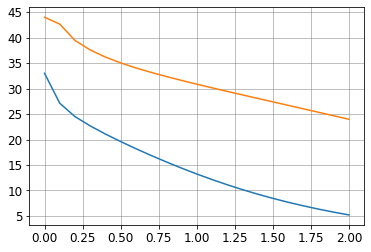

In [30]:
aln = ALNModel()
setparams()
set_init(initvars)

dur = 2.
aln.params['duration'] = dur

control0 = aln.getZeroControl()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:])
plt.plot(aln.t, aln.rates_inh[0,:])
plt.show()

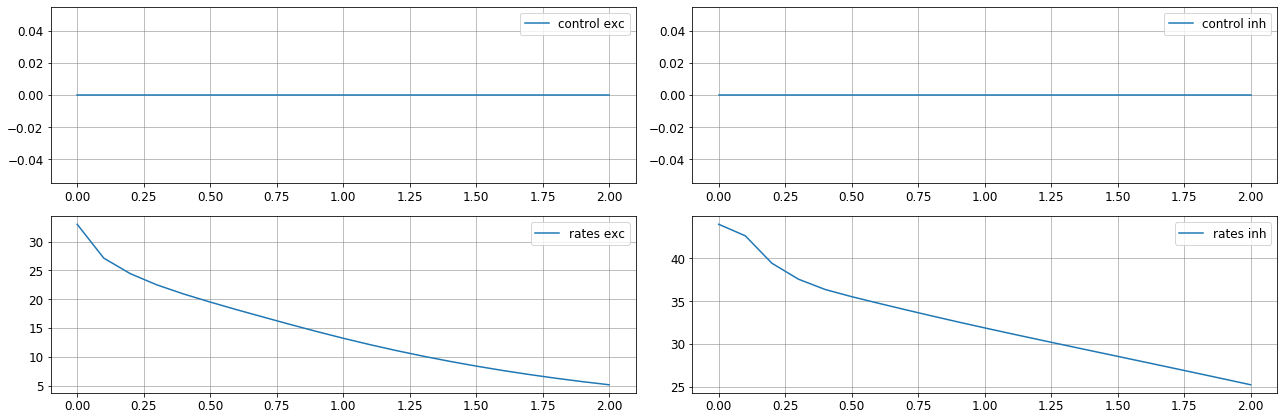

In [31]:
dur_pre = 0.
dur_post = 0.

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

target = aln.getZeroTarget()
control1 = aln.getZeroControl()

set_init(initvars)
setparams()

aln.params.de = 0.2
aln.params.di = 0.4

aln.params.cee = 0.3   #0.3
aln.params.cie = 0.3   #0.3
aln.params.cei = 0.5  #0.5
aln.params.cii = 0.5  #0.5

aln.params.Jee_max = 2.43
aln.params.Jie_max = 2.60
aln.params.Jei_max = -3.3
aln.params.Jii_max = -1.64
    
aln.run(control=control1)
plot_fig(0, control1)
rates0 = np.array( [aln.state["rates_exc"][0,:], aln.state["rates_inh"][0,:]] )

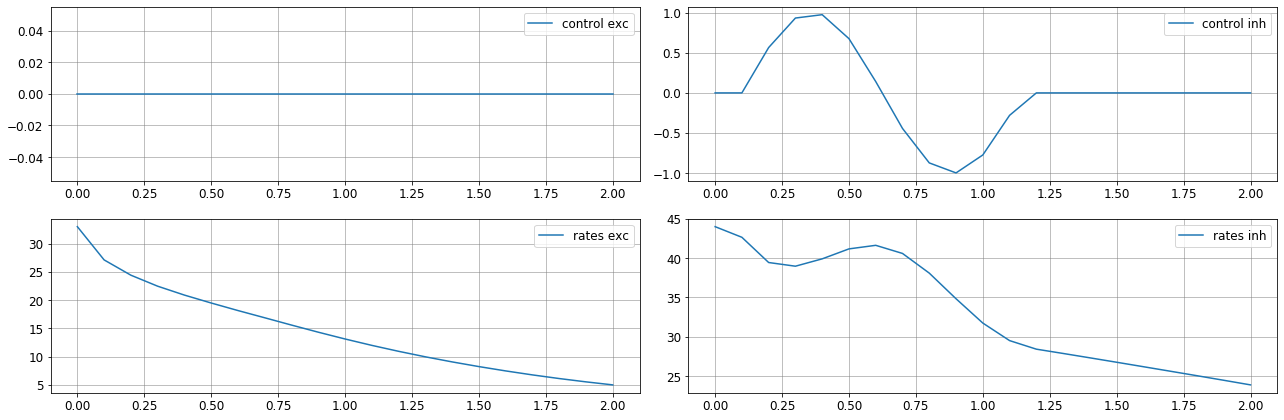

In [32]:
control1 = aln.getZeroControl()
control1[0,1,1] += 4.
control1[0,1,2] += 1.
control1[0,1,3] -= 2.
control1[0,1,4] += 3.
control1[0,1,5] += 2.
control1[0,1,6] -= 3.
control1[0,1,7] -= 1.
control1[0,1,8] -= 4.
control1[0,1,9] += 1.
control1[0,1,10] += 1.
control1[0,1,11] -= 1.
control1[0,1,12] += 2.

control2 = aln.getZeroControl()
control2[0,1,1:12] += np.sin(6.*np.arange(0,1.1,aln.params.dt))

apply_control = control2

aln.run(control=apply_control)
plot_fig(0, apply_control)
plt.savefig("inh_control.png")

rates1 = np.array( [aln.state["rates_exc"][0,:], aln.state["rates_inh"][0,:]] )
target[:,0,:] = aln.state["rates_exc"][0,:]
target[:,1,:] = aln.state["rates_inh"][0,:]

[ 0.      0.      0.      0.      0.      0.      0.      0.     -0.022
 -0.0519 -0.0804 -0.1014 -0.1148 -0.1223 -0.1256 -0.1255 -0.126  -0.1283
 -0.128  -0.123  -0.1171]


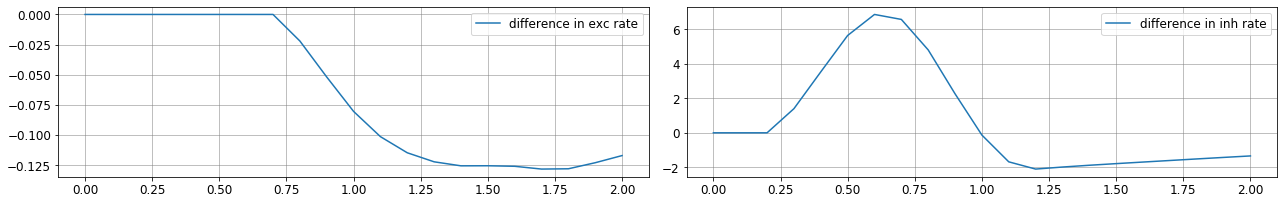

In [33]:
diff = rates1 - rates0
plot_dif(diff)
plt.savefig("diff.png")
print(diff[0,:])

In [34]:
max_cntrl = 50. * 5.
start_step = 100.
tol = 1e-40

cost_params = [1.0, 0.0, 0.0]
cost.setParams(cost_params[0], cost_params[1], cost_params[2])

test_control = aln.getZeroControl()

max_it = 500
set_init(initvars)

A1_bestControl, A1_bestState, A1_cost, runtime = aln.A1(test_control, target, c_scheme, u_mat,
        u_scheme, max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
        max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
        variables_ = [0])

ERROR:root:Not possible to set up initial conditions without sufficient simulation time before control


set cost params
True 4
RUN  0 , total integrated cost =  0.007856555548197525
RUN  1 , total integrated cost =  0.00016157357891916448
too small start step, increase to  10000.0
RUN  2 , total integrated cost =  0.00011070488821186287
RUN  3 , total integrated cost =  9.094160437497647e-05
RUN  4 , total integrated cost =  9.052675682793651e-05
RUN  5 , total integrated cost =  8.649891706277194e-05
RUN  6 , total integrated cost =  7.828564707923423e-05
RUN  7 , total integrated cost =  7.786488877044165e-05
RUN  8 , total integrated cost =  7.716817392390257e-05
RUN  9 , total integrated cost =  7.245768870060017e-05
RUN  10 , total integrated cost =  7.110480537703431e-05
RUN  11 , total integrated cost =  7.080635978329865e-05
too small start step, increase to  10000.0
RUN  12 , total integrated cost =  4.840584913782989e-05
RUN  13 , total integrated cost =  3.853001192870997e-05
RUN  14 , total integrated cost =  3.8449072680846615e-05
RUN  15 , total integrated cost =  3.8022760

RUN  134 , total integrated cost =  7.1164716547096815e-09
RUN  135 , total integrated cost =  7.073568956392278e-09
RUN  136 , total integrated cost =  7.066443379336412e-09
RUN  137 , total integrated cost =  7.046163876116469e-09
RUN  138 , total integrated cost =  6.998145078396443e-09
RUN  139 , total integrated cost =  6.99065831597397e-09
RUN  140 , total integrated cost =  6.9716718002272934e-09
RUN  141 , total integrated cost =  6.9241573017913284e-09
RUN  142 , total integrated cost =  6.917974022294077e-09
RUN  143 , total integrated cost =  6.859730957321967e-09
RUN  144 , total integrated cost =  6.767912709121026e-09
RUN  145 , total integrated cost =  6.762033384701138e-09
RUN  146 , total integrated cost =  6.699553016670316e-09
RUN  147 , total integrated cost =  6.599100256005028e-09
RUN  148 , total integrated cost =  6.59431548033777e-09
too small start step, increase to  10000.0
RUN  149 , total integrated cost =  6.273602907051008e-09
RUN  150 , total integrated 

RUN  264 , total integrated cost =  6.197409748353698e-11
RUN  265 , total integrated cost =  6.180063118211838e-11
RUN  266 , total integrated cost =  6.169912949152058e-11
RUN  267 , total integrated cost =  6.168064276554089e-11
RUN  268 , total integrated cost =  6.157800223460359e-11
RUN  269 , total integrated cost =  6.153602963658352e-11
RUN  270 , total integrated cost =  6.151723729941495e-11
RUN  271 , total integrated cost =  6.140816107616483e-11
RUN  272 , total integrated cost =  6.136831104301602e-11
RUN  273 , total integrated cost =  6.134911080873457e-11
RUN  274 , total integrated cost =  6.123475106441792e-11
RUN  275 , total integrated cost =  6.119667598215886e-11
RUN  276 , total integrated cost =  6.117703257515292e-11
RUN  277 , total integrated cost =  6.105838183819173e-11
RUN  278 , total integrated cost =  6.102177622914158e-11
RUN  279 , total integrated cost =  6.100879169362157e-11
RUN  280 , total integrated cost =  6.073384066008122e-11
RUN  281 , tot

too small start step, increase to  10000.0
RUN  399 , total integrated cost =  2.12445478507731e-11
RUN  400 , total integrated cost =  2.064882152941606e-11
RUN  401 , total integrated cost =  2.0645066568537497e-11
RUN  402 , total integrated cost =  2.063185209092185e-11
RUN  403 , total integrated cost =  2.0589066561702876e-11
RUN  404 , total integrated cost =  2.0583362083639935e-11
RUN  405 , total integrated cost =  2.0576103578139776e-11
RUN  406 , total integrated cost =  2.0534698707591063e-11
RUN  407 , total integrated cost =  2.0524052023962676e-11
RUN  408 , total integrated cost =  2.051984153679228e-11
RUN  409 , total integrated cost =  2.0448987570545535e-11
RUN  410 , total integrated cost =  2.0413106266003536e-11
RUN  411 , total integrated cost =  2.040987435705111e-11
too small start step, increase to  10000.0
RUN  412 , total integrated cost =  1.8488716291935824e-11
RUN  413 , total integrated cost =  1.691983913039967e-11
RUN  414 , total integrated cost =  

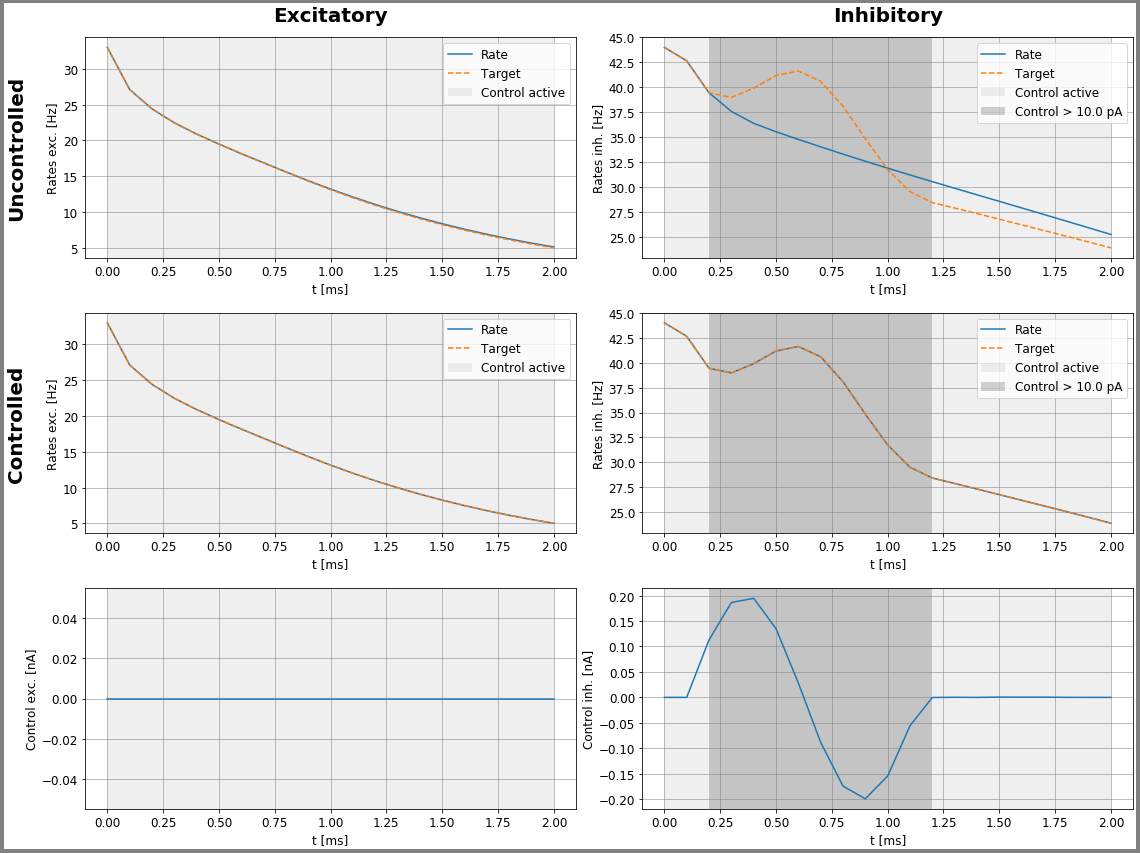

In [35]:
plotFunc.plot_control(aln, A1_bestControl, dur, dur_pre, dur_post, initvars, target,
                      path, filename_ = 'a1_inh.png')

In [1]:
cDiff = apply_control - A1_bestControl
plt.plot(aln.t, cDiff[0,0,:], label="difference exc control")
plt.plot(aln.t, cDiff[0,1,:], label="difference inh control")
plt.legend()
plt.show()

d_int = diff_control(cDiff)
print("control difference = ", d_int)

cDiff[0,1,12:] = 0.
cDiff[0,1,0] = 0.
plt.plot(aln.t, cDiff[0,0,:], label="difference exc control")
plt.plot(aln.t, cDiff[0,1,:], label="difference inh control")
plt.legend()
plt.show()

d_int = diff_control(cDiff)
print("control difference = ", d_int)

NameError: name 'apply_control' is not defined